# Exploring the $P_\mathrm{blue} - \Delta f_\mathrm{b}$ relationship

## Purpose

Can the pair $(\langle P_{\rm blue}\rangle,\langle C\rangle)$, or some similarly compact set of observables, distinguish a change in true blue fraction from a shift in GC color at fixed blue fraction?

## Synthetic experiment

Initially we will keep it simple. For each corrected GMM magnitude bin, generate populations over a grid in:

$$ f_b = 0.1,\ldots,0.9 $$

and

$$ \delta C = -0.15,\ldots,+0.15~{\rm mag}, $$

where $\delta C$ shifts both blue and red Gaussians together while keeping their widths and separation fixed. For each synthetic population measure:

$$ \langle P_{\rm blue}\rangle, \qquad \langle C\rangle, $$

and perhaps the color variance or another simple distribution-shape statistic.

Then we can visualize the mapping from

$$ (f_b,\delta C) $$

into observable space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

# from src.config import (
#     Columns,
#     BCG,
#     AnalysisConfig,
#     ClusterCenter,
# )

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

# N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

In [2]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [4]:
# Set verbosity here:
name = "color_shift_test"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 12:33:20.333 Debug messages are ON
Info messages are always shown
[WARNING] 12:33:20.335 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [5]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [6]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 12:33:28.437 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,imag_simbad_raw,zmag_simbad_raw,gr_simbad_raw,gi_simbad_raw,major_axis_arcsec,galdim_minaxis,galdim_angle,dim_source,galdim_qual,galdim_bibcode,dim_ref,MV_simbad_raw,show_label,Re_arcsec,otype_family,morph_type,major_kpc,is_large_E,sdss_objid,Re_r_arcsec,Re_r_arcsec_circ,g_cmodel_sdss,r_cmodel_sdss,i_cmodel_sdss,gerr_cmodel_sdss,rerr_cmodel_sdss,ierr_cmodel_sdss,Ag_sdss,Ar_sdss,Ai_sdss,g0_cmodel_sdss,r0_cmodel_sdss,i0_cmodel_sdss,sdss_phot_ok,gr0_sdss,gi0_sdss,g_model_sdss,r_model_sdss,i_model_sdss,gerr_model_sdss,rerr_model_sdss,ierr_model_sdss,g0_model_sdss,r0_model_sdss,i0_model_sdss,Vmag_sdss,Vmag_sdss_err,V_source,mV_app,mV_src,mV_app_col,gi_primary,gr_primary,color_src,MV_abs,Re_simbad_proxy_arcsec,Re_best_arcsec,Re_best_src,Re_best_is_proxy,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,11.660,11.1535,0.849299,0.9872,140.404205,2.260740,63.0,SIMBAD,B,2023ApJS..269....3M,NaN,-22.29,True,17.550526,Active (AGN/Seyfert/QSO),NaN,69955.709614,True,1.237667e+18,29.679890,29.586330,12.91115,12.10644,11.64227,0.001805,0.001734,0.001839,0.030093,0.020818,0.015470,12.881057,12.085622,11.626800,True,0.795435,1.254257,12.79304,11.98041,11.52575,0.001763,0.001691,0.001796,12.762947,11.959592,11.510280,12.401750,0.001263,"SDSS(cModelMag g,r)",12.401750,SDSS,Vmag_sdss,1.254257,0.795435,SDSS(cModel extcorr),-22.598250,17.550526,29.586330,SDSS,False,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,13.195,12.9140,0.805000,1.2340,49.683781,0.690853,47.0,SIMBAD,B,2023ApJS..269....3M,NaN,-21.48,True,6.210473,Regular galaxies,NaN,23717.064621,False,1.237667e+18,7.956479,7.458112,14.35112,13.44835,13.10265,0.002027,0.001773,0.001854,0.037900,0.026219,0.019484,14.313220,13.422131,13.083166,True,0.891089,1.230054,14.31396,13.44071,13.06010,0.002010,0.001768,0.001850,14.276060,13.414491,13.040616,13.777477,0.001336,"SDSS(cModelMag g,r)",13.777477,SDSS,Vmag_sdss,1.230054,0.891089,SDSS(cModel extcorr),-21.222523,6.210473,7.458112,SDSS,False,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,11.527,10.8346,0.851100,0.8258,175.404602,1.816900,75.0,SIMBAD,B,2023ApJS..269....3M,NaN,-23.70,True,21.925575,Regular galaxies,NaN,78815.629278,True,1.237667e+18,29.678560,23.026233,12.42321,11.59573,11.37449,0.001674,0.001673,0.001774,0.031663,0.021904,0.016277,12.391547,11.573826,11.358213,True,0.817721,1.033334,12.34061,11.51430,11.21793,0.001639,0.001641,0.001738,12.308947,11.492396,11.201653,11.899091,0.001202,"SDSS(cModelMag g,r)",11.899091,SDSS,Vmag_sdss,1.033334,0.817721,SDSS(cModel extcorr),-23.100909,21.925575,23.026233,SDSS,False,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,16.672,16.5390,0.637001,0.9760,19.498001,0.324967,0.0,SIMBAD,E,2022ApJS..262...36S,NaN,-16.76,False,2.437250,LSB/BCD/Dwarf,NaN,8443.755209,False,1.237667e+18,11.911510,10.328826,17.68241,17.11709,16.79583,0.012078,0.010989,0.013028,0.037577,0.025995,0.019317,17.644833,17.091095,16.776513,True,0.553739,0.868321,17.64823,17.01133,16.67162,0.011933,0.010760,0.012651,17.610653,16.985335,16.652303,17.308127,0.008158,"SDSS(cModelMag g,r)",17.308127,SDSS,Vmag_sdss,0.868321,0.553739,SDSS(cModel extcorr),-17.691873,2.437250,10.328826,SDSS,False,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MANUAL,NaN,NaN,NaN,NaN,False,NaN,Other,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN

In [7]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [8]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [9]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [10]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [11]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [12]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

# Create a synthetic population for testing

Initially, ignore the real GC catalogue entirely and generate a synthetic population for one magnitude bin using that bin’s corrected blue/red Gaussian parameters.

In [13]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(20260901)

# Corrected GMM parameters for 24-25 mag bin
mu_b = 1.457
sig_b = 0.176

mu_r = 1.668
sig_r = 0.246

f_blue_true = 0.50
N_SYN = 50_000

# Draw true component labels
is_blue = rng.random(N_SYN) < f_blue_true

# Generate synthetic colors
color_syn = np.empty(N_SYN)

color_syn[is_blue] = rng.normal(
    loc=mu_b,
    scale=sig_b,
    size=is_blue.sum()
)

color_syn[~is_blue] = rng.normal(
    loc=mu_r,
    scale=sig_r,
    size=(~is_blue).sum()
)

# Give all objects a magnitude inside the same GMM bin
mag_syn = rng.uniform(
    24.0,
    25.0,
    size=N_SYN
)

synthetic_gc = pd.DataFrame({
    "mag_814": mag_syn,
    "color": color_syn,
    "true_blue": is_blue,
})


## Add $P_\mathrm{blue}$ to CSS data

In [14]:
# import numpy as np
# from typing import Tuple, Optional, Callable
# from src.color_metrics import compute_Pblue

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
#
    # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
    #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
    #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
    #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
    #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
    # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [15]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=synthetic_gc["mag_814"].values,
    color=synthetic_gc["color"].values
)

synthetic_gc = synthetic_gc.copy()
synthetic_gc["Pblue"] = Pblue_all


Sanity check...

In [16]:
print(f"True blue fraction   = {synthetic_gc['true_blue'].mean():.4f}")
print(f"Mean Pblue           = {synthetic_gc['Pblue'].mean():.4f}")
print(f"Median Pblue         = {synthetic_gc['Pblue'].median():.4f}")


True blue fraction   = 0.4966
Mean Pblue           = 0.5612
Median Pblue         = 0.6581


## Split by true component as well.

This effectively gives the empirical $A_b$ and $A_r$.

In [17]:
print(
    "Mean Pblue | true blue =",
    synthetic_gc.loc[
        synthetic_gc["true_blue"],
        "Pblue"
    ].mean()
)

print(
    "Mean Pblue | true red  =",
    synthetic_gc.loc[
        ~synthetic_gc["true_blue"],
        "Pblue"
    ].mean()
)

Mean Pblue | true blue = 0.6775767060817597
Mean Pblue | true red  = 0.44640492260141357


## No color shifts - baseline $f_\mathrm{b}$ relationship


In [21]:
fb_grid = np.linspace(0.1, 0.9, 9)

rows = []

for fb in fb_grid:

    is_blue = rng.random(N_SYN) < fb

    color = np.empty(N_SYN)

    color[is_blue] = rng.normal(
        mu_b, sig_b, is_blue.sum()
    )

    color[~is_blue] = rng.normal(
        mu_r, sig_r, (~is_blue).sum()
    )

    mag = rng.uniform(24.0, 25.0, N_SYN)

    pblue, _ = compute_Pblue(
        mag,
        color,
    )

    rows.append({
        "f_blue_true": fb,
        "mean_color": np.mean(color),
        "mean_Pblue": np.mean(pblue),
    })

cal_df = pd.DataFrame(rows)

pd.set_option("display.notebook_repr_html", False)
display(cal_df)


   f_blue_true  mean_color  mean_Pblue
0          0.1    1.646691    0.469399
1          0.2    1.625132    0.493045
2          0.3    1.603611    0.516392
3          0.4    1.583641    0.538722
4          0.5    1.563164    0.561021
5          0.6    1.542512    0.584331
6          0.7    1.520301    0.607121
7          0.8    1.499034    0.630456
8          0.9    1.478759    0.653375

In [22]:
coef = np.polyfit(
    cal_df["f_blue_true"],
    cal_df["mean_Pblue"],
    1,
)

slope, intercept = coef

print(f"slope     = {slope:.6f}")
print(f"intercept = {intercept:.6f}")


slope     = 0.229201
intercept = 0.446940


So, for the mean color, we can write the result down analytically, i.e., with the 24–25 bin parameters,

$$ \mu_b = 1.457,\qquad \mu_r = 1.668, $$

the expected mixture mean is

$$ \langle C\rangle = f_b\mu_b+(1-f_b)\mu_r $$

or

$$ \langle C\rangle = 1.668-0.211\,f_b. $$

The simulated values used above follow that almost perfectly.

More importantly, mean $P_{\rm blue}$ behaves similarly:

$$ \langle P_{\rm blue}\rangle \simeq A_r + f_b(A_b-A_r). $$

From the results table, the linear fit is approximately

$$ \langle P_{\rm blue}\rangle \simeq 0.447 + 0.229\,f_b. $$

So a true blue-fraction range of

$$ f_b=0.1\rightarrow0.9 $$

only produces

$$ \langle P_{\rm blue}\rangle \simeq0.47\rightarrow0.65. $$

That is the compression which we already proved, but crucially, because it is monotonic, we can invert it:

$$ \hat f_b \simeq \frac{\langle P_{\rm blue}\rangle-0.447}{0.229}. $$

So on the narrow question, “can mean $P_{\rm blue}$ be calibrated back to a true mixture fraction if the GMM component locations and widths are correct?” — the answer is clearly yes.


## Recovered Fraction

In [23]:
cal_df["f_blue_recovered"] = (
    cal_df["mean_Pblue"] - intercept
) / slope

cal_df["Delta_f"] = (
    cal_df["f_blue_recovered"]
    - cal_df["f_blue_true"]
)

print(
    cal_df[
        [
            "f_blue_true",
            "mean_Pblue",
            "f_blue_recovered",
            "Delta_f",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)


 f_blue_true  mean_Pblue  f_blue_recovered  Delta_f
     0.10000     0.46940           0.09799 -0.00201
     0.20000     0.49304           0.20115  0.00115
     0.30000     0.51639           0.30302  0.00302
     0.40000     0.53872           0.40045  0.00045
     0.50000     0.56102           0.49774 -0.00226
     0.60000     0.58433           0.59944 -0.00056
     0.70000     0.60712           0.69887 -0.00113
     0.80000     0.63046           0.80068  0.00068
     0.90000     0.65338           0.90067  0.00067


# Hold $f_\mathrm{b}$ fixed and shift color

So, with a fixed color, $f_\mathrm{b}$ can be recovered with a good level of certainty - i.e., from above all residuals are <2%. Thus the question becomes,  "Can a coherent shift in the GC color distribution fool this calibration into reporting a different blue fraction?"

So now we fix $f_\mathrm{b}$, say,

$$ f_b = 0.5 $$

and shift both Gaussian means together by

$$ \Delta C = -0.15,\ldots,+0.15. $$

Then for each shift:

- generate the synthetic population,
- calculate $\langle P_{\rm blue}\rangle$ using the original unshifted GMM,
- feed that mean through the calibration you just derived,
- record the apparent recovered $f_b$.


In [26]:
fb_fixed = 0.5
shift_grid = np.linspace(-0.15, 0.15, 13)

rows = []

for dC in shift_grid:

    is_blue = rng.random(N_SYN) < fb_fixed

    color = np.empty(N_SYN)

    color[is_blue] = rng.normal(
        mu_b + dC,
        sig_b,
        is_blue.sum()
    )

    color[~is_blue] = rng.normal(
        mu_r + dC,
        sig_r,
        (~is_blue).sum()
    )

    mag = rng.uniform(24.0, 25.0, N_SYN)

    pblue, _ = compute_Pblue(
        mag,
        color,
    )

    mean_pblue = np.mean(pblue)

    fb_recovered = (
        mean_pblue - intercept
    ) / slope

    rows.append({
        "delta_color": dC,
        "mean_color": np.mean(color),
        "mean_Pblue": mean_pblue,
        "f_blue_recovered": fb_recovered,
        "Delta_f": fb_recovered - fb_fixed,
    })

shift_df = pd.DataFrame(rows)

print(
    shift_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)


 delta_color  mean_color  mean_Pblue  f_blue_recovered  Delta_f
    -0.15000     1.41227     0.66892           0.96848  0.46848
    -0.12500     1.43682     0.65553           0.91006  0.41006
    -0.10000     1.46294     0.63918           0.83876  0.33876
    -0.07500     1.48779     0.62206           0.76403  0.26403
    -0.05000     1.51299     0.60288           0.68037  0.18037
    -0.02500     1.53736     0.58326           0.59476  0.09476
     0.00000     1.56227     0.56211           0.50247  0.00247
     0.02500     1.58859     0.53811           0.39779 -0.10221
     0.05000     1.61328     0.51443           0.29446 -0.20554
     0.07500     1.63664     0.49086           0.19160 -0.30840
     0.10000     1.66087     0.46601           0.08319 -0.41681
     0.12500     1.68804     0.43729          -0.04211 -0.54211
     0.15000     1.71190     0.41186          -0.15305 -0.65305


This is the degeneracy we have already proved, but this is justfication for creating a 2D calibration model, to see if mean color itself can be used as a second observable to break the degeneracy.

# Create a 2D calibration



In [30]:
fb_grid = np.linspace(0.1, 0.9, 9)
shift_grid = np.linspace(-0.15, 0.15, 13)

rows = []

for fb in fb_grid:
    
    for dC in shift_grid:
    
        is_blue = rng.random(N_SYN) < fb
    
        color = np.empty(N_SYN)
    
        color[is_blue] = rng.normal(
            mu_b + dC,
            sig_b,
            is_blue.sum()
        )
    
        color[~is_blue] = rng.normal(
            mu_r + dC,
            sig_r,
            (~is_blue).sum()
        )
    
        mag = rng.uniform(24.0, 25.0, N_SYN)
    
        pblue, _ = compute_Pblue(
            mag,
            color,
        )
    
        mean_pblue = np.mean(pblue)
    
        fb_recovered_1d = (
            mean_pblue - intercept
        ) / slope
    
        rows.append({
            "f_blue_true": fb,
            "delta_color": dC,
            "mean_color": np.mean(color),
            "mean_Pblue": mean_pblue,
            "f_blue_recovered_1d": fb_recovered_1d,
            "Delta_f": fb_recovered_1d - fb,
        })


fb_C_shift_2D_df = pd.DataFrame(rows)


In [31]:
print(
    fb_C_shift_2D_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.5f}",
    )
)

 f_blue_true  delta_color  mean_color  mean_Pblue  f_blue_recovered_1d  Delta_f
     0.10000     -0.15000     1.49842     0.60253              0.67885  0.57885
     0.10000     -0.12500     1.52169     0.58450              0.60017  0.50017
     0.10000     -0.10000     1.54593     0.56530              0.51639  0.41639
     0.10000     -0.07500     1.57238     0.54174              0.41361  0.31361
     0.10000     -0.05000     1.59817     0.51649              0.30343  0.20343
     0.10000     -0.02500     1.62260     0.49353              0.20327  0.10327
     0.10000      0.00000     1.64684     0.46873              0.09507 -0.00493
     0.10000      0.02500     1.67147     0.44438             -0.01118 -0.11118
     0.10000      0.05000     1.69829     0.41703             -0.13049 -0.23049
     0.10000      0.07500     1.72342     0.39078             -0.24504 -0.34504
     0.10000      0.10000     1.74582     0.36774             -0.34555 -0.44555
     0.10000      0.12500     1.77289   

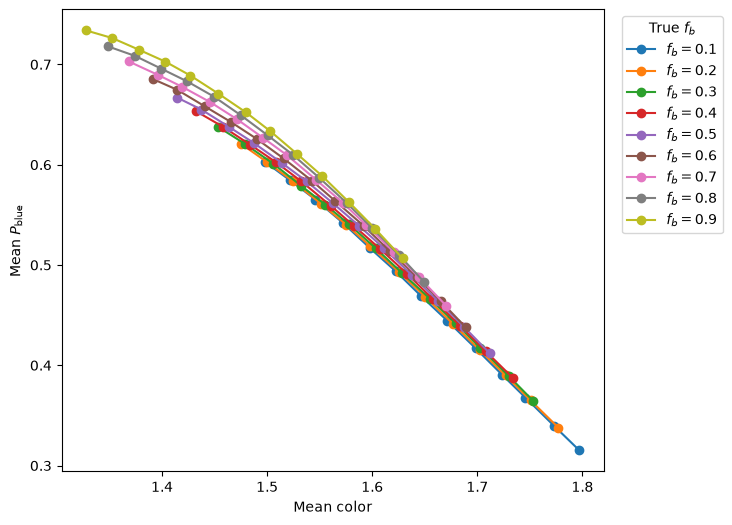

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))

for fb, group in fb_C_shift_2D_df.groupby("f_blue_true"):

    group = group.sort_values("delta_color")

    ax.plot(
        group["mean_color"],
        group["mean_Pblue"],
        marker="o",
        label=fr"$f_b={fb:.1f}$"
    )

ax.set_xlabel(r"Mean color")
ax.set_ylabel(r"Mean $P_{\rm blue}$")
ax.legend(
    title=r"True $f_b$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()


The curves above merge and thus even the 2D calibration would not be able to recover the blue fraction from $P_\mathrm{blue}$ and $\Delta C$. So the next step is to identify if there is another quantity which can break the degeneracy. We'll start with color variance, because a common color shift doesn't change the variance at all, but changing the blue fraction of the two GMM does.

# Shape-statistic: Variance

In [33]:
fb_grid = np.linspace(0.1, 0.9, 9)
shift_grid = np.linspace(-0.15, 0.15, 13)

rows = []

for fb in fb_grid:
    
    for dC in shift_grid:
    
        is_blue = rng.random(N_SYN) < fb
    
        color = np.empty(N_SYN)
    
        color[is_blue] = rng.normal(
            mu_b + dC,
            sig_b,
            is_blue.sum()
        )
    
        color[~is_blue] = rng.normal(
            mu_r + dC,
            sig_r,
            (~is_blue).sum()
        )
    
        mag = rng.uniform(24.0, 25.0, N_SYN)
    
        pblue, _ = compute_Pblue(
            mag,
            color,
        )
    
        mean_pblue = np.mean(pblue)
    
        fb_recovered_1d = (
            mean_pblue - intercept
        ) / slope
    
        rows.append({
            "f_blue_true": fb,
            "delta_color": dC,
            "mean_color": np.mean(color),
            "mean_Pblue": mean_pblue,
            "f_blue_recovered_1d": fb_recovered_1d,
            "Delta_f": fb_recovered_1d - fb,
            "color_std": np.std(color, ddof=1),
            "color_var": np.var(color, ddof=1),
        })


fb_C_shift_w_var_df = pd.DataFrame(rows)


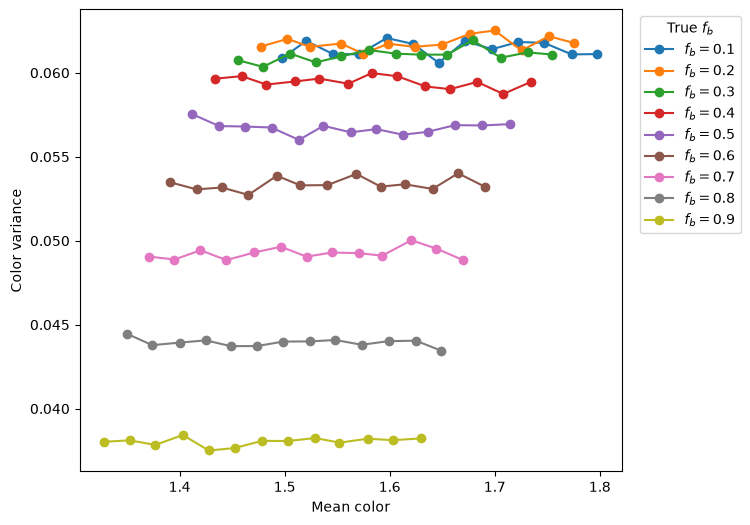

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))

for fb, group in fb_C_shift_w_var_df.groupby("f_blue_true"):

    group = group.sort_values("delta_color")

    ax.plot(
        group["mean_color"],
        group["color_var"],
        marker="o",
        label=fr"$f_b={fb:.1f}$"
    )

ax.set_xlabel("Mean color")
ax.set_ylabel("Color variance")

ax.legend(
    title=r"True $f_b$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()


# Shape-statistic: Skewness

In [39]:
from scipy.stats import skew

fb_grid = np.linspace(0.1, 0.9, 9)
shift_grid = np.linspace(-0.15, 0.15, 13)

rows = []

for fb in fb_grid:
    
    for dC in shift_grid:
    
        is_blue = rng.random(N_SYN) < fb
    
        color = np.empty(N_SYN)
    
        color[is_blue] = rng.normal(
            mu_b + dC,
            sig_b,
            is_blue.sum()
        )
    
        color[~is_blue] = rng.normal(
            mu_r + dC,
            sig_r,
            (~is_blue).sum()
        )
    
        mag = rng.uniform(24.0, 25.0, N_SYN)
    
        pblue, _ = compute_Pblue(
            mag,
            color,
        )
    
        mean_pblue = np.mean(pblue)
    
        fb_recovered_1d = (
            mean_pblue - intercept
        ) / slope
    
        rows.append({
            "f_blue_true": fb,
            "delta_color": dC,
            "mean_color": np.mean(color),
            "mean_Pblue": mean_pblue,
            "f_blue_recovered_1d": fb_recovered_1d,
            "Delta_f": fb_recovered_1d - fb,
            "color_std": np.std(color, ddof=1),
            "color_var": np.var(color, ddof=1),
            "color_skew": skew(color, bias=False),
        })


fb_C_shift_w_skew_df = pd.DataFrame(rows)


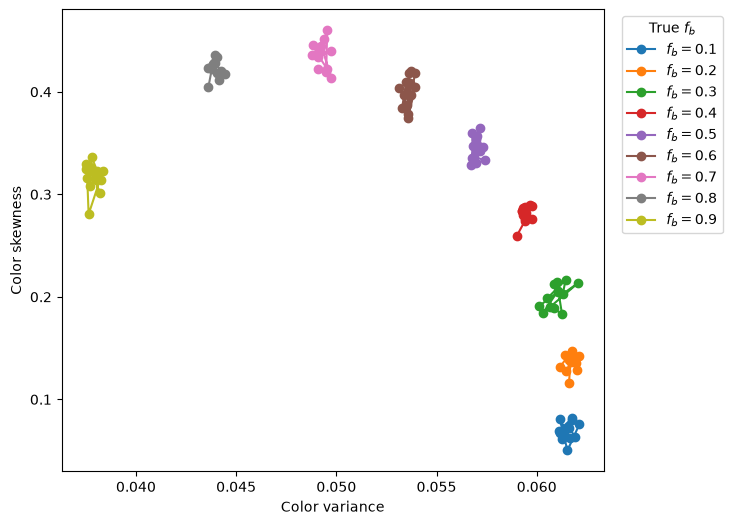

In [40]:
fig, ax = plt.subplots(figsize=(7, 6))

for fb, group in fb_C_shift_w_skew_df.groupby("f_blue_true"):

    group = group.sort_values("delta_color")

    ax.plot(
        group["color_var"],
        group["color_skew"],
        marker="o",
        label=fr"$f_b={fb:.1f}$"
    )

ax.set_xlabel("Color variance")
ax.set_ylabel("Color skewness")

ax.legend(
    title=r"True $f_b$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.show()

# Quantify seperability


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error, r2_score

X = fb_C_shift_w_skew_df[
    ["color_var", "color_skew"]
].to_numpy()

y = fb_C_shift_w_skew_df[
    "f_blue_true"
].to_numpy()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

y_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

print(f"MAE = {mean_absolute_error(y, y_pred):.4f}")
print(f"R^2 = {r2_score(y, y_pred):.4f}")


MAE = 0.0014
R^2 = 0.9997


So this works well for the sample size, but realistically, this is going to introduce too much noise, especially for skewness, and the shape-statistics are unlikely to contain enough information down to our lower GC-count limit (of 10 GCs in a GCS). It would be useful to quantify the threshold of, say, large, intermediate and small GCS where this method fails. It is likely to work well for larger galaxies, but fail completely for the smaller GCS.

# Quantify $N_\mathrm{GC}$ regimes for classification


In [43]:
import itertools

fb_grid = np.linspace(0.1, 0.9, 9)
shift_grid = np.linspace(-0.15, 0.15, 13)
N_grid = [10, 20, 30, 50, 100, 200, 500]

N_REAL = 500

rows = []

grid = list(itertools.product(N_grid, fb_grid, shift_grid))

for N, fb, dC in tqdm(
    grid,
    total=len(grid),
    desc="Synthetic populations"
):
    for realization in range(N_REAL):

        is_blue = rng.random(N) < fb

        color = np.empty(N)

        color[is_blue] = rng.normal(
            mu_b + dC,
            sig_b,
            is_blue.sum()
        )

        color[~is_blue] = rng.normal(
            mu_r + dC,
            sig_r,
            (~is_blue).sum()
        )

        mag = rng.uniform(
            24.0,
            25.0,
            N
        )

        pblue, _ = compute_Pblue(
            mag,
            color,
        )

        mean_pblue = np.mean(pblue)

        fb_recovered_1d = (
            mean_pblue - intercept
        ) / slope

        rows.append({
            "N_GC": N,
            "realization": realization,
            "f_blue_true": fb,
            "delta_color": dC,
            "mean_color": np.mean(color),
            "mean_Pblue": mean_pblue,
            "f_blue_recovered_1d": fb_recovered_1d,
            "Delta_f_1d": fb_recovered_1d - fb,
            "color_std": np.std(color, ddof=1),
            "color_var": np.var(color, ddof=1),
            "color_skew": skew(color, bias=False),
        })

fb_C_shift_w_NGC_df = pd.DataFrame(rows)

Synthetic populations:   0%|          | 0/819 [00:00<?, ?it/s]

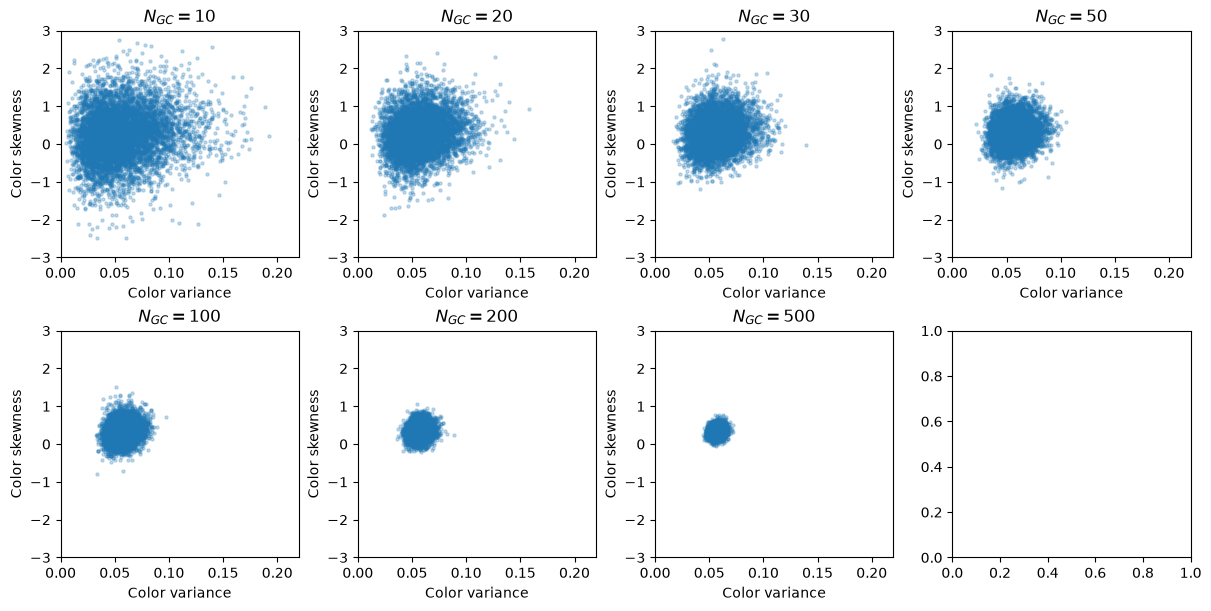

In [46]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(12, 6),
    constrained_layout=True
)

for ax, N in zip(axes.flat, N_grid):

    sub = fb_C_shift_w_NGC_df[
        (fb_C_shift_w_NGC_df["N_GC"] == N)
        & (fb_C_shift_w_NGC_df["f_blue_true"] == 0.5)
    ]

    ax.scatter(
        sub["color_var"],
        sub["color_skew"],
        s=5,
        alpha=0.25
    )

    ax.set_xlim(0,0.22)
    ax.set_ylim(-3,3)

    ax.set_title(fr"$N_{{GC}}={N}$")
    ax.set_xlabel("Color variance")
    ax.set_ylabel("Color skewness")

plt.show()


This shows the shrinkage with $N_{\rm GC}$ very clearly, although the the result is pretty much expected:

- At $N_{\rm GC}=10$, variance/skewness space is basically useless for precise recovery. The cloud is enormous.
- $N=20$ and $30$ are better, but still very broad.
- By $N\sim50$, the cloud is starting to tighten enough that shape information may become informative.
- $N\sim100$ looks much more promising.
- $N\ge200$ is clearly in the regime where the shape statistics become stable.

So , in summary, a shape-based calibrated $f_b$ estimator is probably only viable for the richer systems.

There’s one important caveat with this particular result: what is plotted is all $f_b$ values and all color shifts together in the same color. So this shows the overall sampling noise shrinking with $N$, but it doesn’t yet tell us whether the different true $f_b$ populations are actually separable at each $N$.


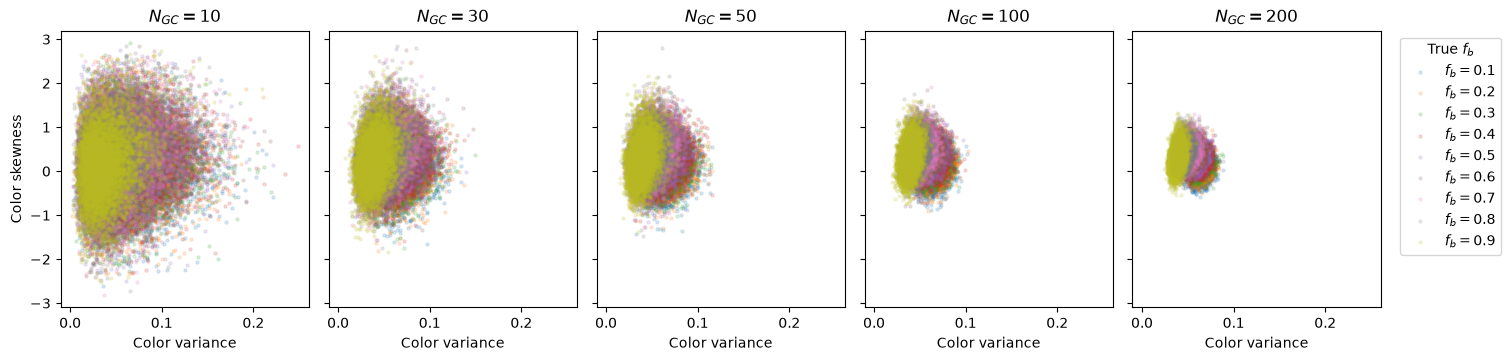

In [47]:
N_show = [10, 30, 50, 100, 200]

fig, axes = plt.subplots(
    1, len(N_show),
    figsize=(15, 3.5),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for ax, N in zip(axes, N_show):

    sub_N = fb_C_shift_w_NGC_df[
        fb_C_shift_w_NGC_df["N_GC"] == N
    ]

    for fb, group in sub_N.groupby("f_blue_true"):

        ax.scatter(
            group["color_var"],
            group["color_skew"],
            s=5,
            alpha=0.15,
            label=fr"$f_b={fb:.1f}$"
        )

    ax.set_title(fr"$N_{{GC}}={N}$")
    ax.set_xlabel("Color variance")

axes[0].set_ylabel("Color skewness")

axes[-1].legend(
    title=r"True $f_b$",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

## How many GCs are needed for (useful) shape-based recovery?

In [55]:
N_show = [10, 30, 50, 100, 200, 500]

results = []

for N in N_show:

    sub = fb_C_shift_w_NGC_df[
        fb_C_shift_w_NGC_df["N_GC"] == N
    ].copy()

    X = sub[
        ["color_var", "color_skew"]
    ].to_numpy()

    y = sub[
        "f_blue_true"
    ].to_numpy()

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=cv
    )

    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    delta = y_pred - y
    
    results.append({
        "N_GC": N,
        "MAE": mae,
        "R2": r2,
        "bias": np.mean(delta),
        "median": np.median(delta),
        "sigma": np.std(delta, ddof=1),
        "p16": np.percentile(delta, 16),
        "p84": np.percentile(delta, 84),
    })

    print(
        f"N_GC={N:3d}  "
        f"MAE={mae:.4f}  "
        f"R2={r2:.4f}"
    )

recovery_df = pd.DataFrame(results)


N_GC= 10  MAE=0.2202  R2=-0.0407
N_GC= 30  MAE=0.1916  R2=0.1668
N_GC= 50  MAE=0.1706  R2=0.3149
N_GC=100  MAE=0.1383  R2=0.5283
N_GC=200  MAE=0.1071  R2=0.7062
N_GC=500  MAE=0.0720  R2=0.8621


This Distribution-shape information can recover true mixture fraction, but only for relatively rich GC systems. For sparse systems, the uncertainty is too large for reliable galaxy-by-galaxy $f_b$ estimation.

This supports the hybrid strategy which I've been heading towards...

- use calibrated/shape-based $f_b$ only for richer galaxies;
- retain $P_{\rm blue}$ as the more stable proxy diagnostic for the low-count majority;
- avoid pretending every galaxy supports a literal blue-fraction measurement.

**This means toning down the literal $f_b$ statements**


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_272/2247909359.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


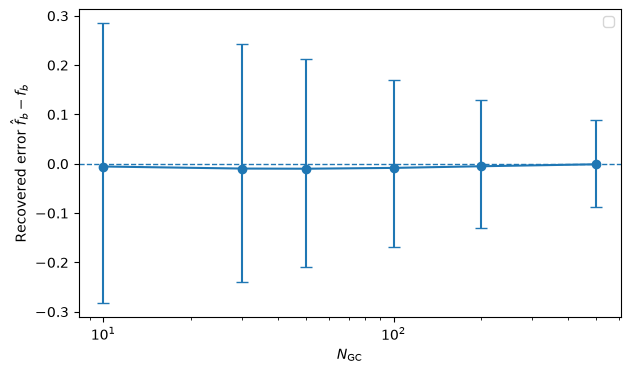

In [57]:
fig, ax = plt.subplots(figsize=(7, 4))

# ax.plot(
#     recovery_df["N_GC"],
#     recovery_df[["MAE","R2"]],
#     marker="o",
#     label=["MAE",r"$R^2$"]
# )

y = recovery_df["median"]

yerr = np.vstack([
    y - recovery_df["p16"],
    recovery_df["p84"] - y,
])

ax.errorbar(
    recovery_df["N_GC"],
    y,
    yerr=yerr,
    marker="o",
    capsize=4,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xscale("log")
ax.set_xlabel(r"$N_{\rm GC}$")
ax.set_ylabel(r"Recovered error $\hat f_b-f_b$")
ax.legend()

plt.show()
# ax.set_ylabel(r"MAE in recovered $f_b$")




# Summary: Recovering $f_b$ from color-distribution shape

The synthetic tests show that the compression of mean $P_{\rm blue}$ relative to the true blue fraction is not, by itself, a fundamental limitation. In the large-sample limit, the relation between mean $P_{\rm blue}$ and $f_b$ is monotonic and can be calibrated accurately. However, a coherent shift in both blue and red component colors produces a strong degeneracy: relatively small color shifts can mimic large changes in the inferred blue fraction. A one-dimensional calibration of mean $P_{\rm blue}$ therefore cannot uniquely recover a physical $f_b$ when the component means are allowed to vary.

Adding translation-invariant shape information partly breaks this degeneracy. In particular, the color variance contains most of the information about $f_b$, while skewness helps distinguish regions where the variance–fraction relation is non-monotonic. In the idealized large-$N$ limit, the combination of variance and skewness can recover the input mixture fraction extremely well. This demonstrates that the problem is not fundamentally non-identifiable once distribution shape is included.

The practical limitation is finite sample size. Simulations spanning $N_{\rm GC}=10$–500 show that the uncertainty on shape-based $f_b$ recovery remains large over most of the range relevant to the galaxy sample. At $N_{\rm GC}=10$ the predictor performs no better than predicting the mean population fraction, while useful predictive power only emerges gradually for richer systems. Even at $N_{\rm GC}\sim100$–200, the typical recovery error remains of order $0.1$–$0.15$ in $f_b$, and a substantial 16–84 percentile range persists. The estimator is approximately unbiased, but imprecise.

These tests therefore support retaining mean $P_{\rm blue}$ as a robust mixture/color proxy rather than interpreting it as a literal blue-subpopulation fraction for every galaxy. Shape-based recovery may still provide an independent validation for the richest GC systems, but the current minimum sample size of 10 objects is far too small for reliable galaxy-by-galaxy inference of true $f_b$. Any revised interpretation should distinguish clearly between the observable proxy and the latent physical mixture fraction.


# Working conclusion

> The referee’s concern about interpreting $\Delta f_b$ as a direct blue-fraction measurement is justified. The proxy remains useful, but its physical interpretation must be softened unless restricted to substantially richer GC systems or replaced by a more explicit mixture model.